# Key Business Questions


## This project aims to answer five key business questions:

* Which markets generate the highest revenue?
* Which products contribute most to sales?
* Which customer segments drive business growth?
* How do sales change over time?
* Which insights are statistically significant?

# Data & Method

## Data Source

This project uses the Google BigQuery e-commerce dataset provided by Data Analytics Mate. The dataset contains information about website sessions, customer accounts, products, orders, traffic sources, and user behavior.

## Dataset Construction

The analytical dataset was created by joining multiple relational tables from BigQuery. The final dataset combines session, customer, product, and order information into a single table for further analysis.

In [ ]:
# ============================================================
# Import libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.cloud import bigquery
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

In [ ]:
# ============================================================
# Authenticate Google Account
# ============================================================

auth.authenticate_user()

In [ ]:
# ============================================================
# Create BigQuery Client
# ============================================================

PROJECT_ID = "data-analytics-mate"

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
# ==========================================================
# SQL Data Extraction
# ==========================================================

query = """

SELECT

    s.date AS order_date,
    s.ga_session_id AS session_id,

    sp.continent AS continent,
    sp.country AS country,
    sp.device AS device,
    sp.browser AS browser,
    sp.mobile_model_name AS device_model,
    sp.operating_system AS operating_system,
    sp.language AS language,
    sp.name AS traffic_source,
    sp.channel AS traffic_channel,

    acc.id AS user_id,
    acc.is_verified AS confirmed_email,
    acc.is_unsubscribed AS newsletter_unsubscribed,

    p.category AS product_category,
    p.name AS product_name,
    p.price AS price,
    p.short_description AS product_description

FROM `data-analytics-mate.DA.session` s

LEFT JOIN `data-analytics-mate.DA.account_session` acs
       ON s.ga_session_id = acs.ga_session_id

LEFT JOIN `data-analytics-mate.DA.account` acc
       ON acs.account_id = acc.id

LEFT JOIN `data-analytics-mate.DA.session_params` sp
       ON s.ga_session_id = sp.ga_session_id

LEFT JOIN `data-analytics-mate.DA.order` o
       ON s.ga_session_id = o.ga_session_id

LEFT JOIN `data-analytics-mate.DA.product` p
       ON o.item_id = p.item_id

ORDER BY order_date

"""


In [ ]:
# ==========================================================
# Create Analytical Dataset
# ==========================================================
job = client.query(query)
df = job.result().to_dataframe(create_bqstorage_client=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique sessions: {df['session_id'].nunique():,}")

df.info()
df.head()

Rows: 349,545
Columns: 18
Unique sessions: 349,545
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_date               349545 non-null  dbdate 
 1   session_id               349545 non-null  Int64  
 2   continent                349545 non-null  object 
 3   country                  349545 non-null  object 
 4   device                   349545 non-null  object 
 5   browser                  349545 non-null  object 
 6   device_model             349545 non-null  object 
 7   operating_system         349545 non-null  object 
 8   language                 235279 non-null  object 
 9   traffic_source           349545 non-null  object 
 10  traffic_channel          349545 non-null  object 
 11  user_id                  27945 non-null   Int64  
 12  confirmed_email          27945 non-null   Int64  
 13  newslett

,order_date,session_id,continent,country,device,browser,device_model,operating_system,language,traffic_source,traffic_channel,user_id,confirmed_email,newsletter_unsubscribed,product_category,product_name,price,product_description
0,2020-11-01,65223751,Americas,United States,mobile,Chrome,<Other>,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


## Dataset Overview

The analytical dataset contains 349,545 rows and 18 variables. It combines session, traffic source, customer, and product information extracted from multiple relational tables in BigQuery. Each row corresponds to a unique session — no session appears more than once in the dataset.

Some missing values are expected because:

- customer information is available only for registered users;
- product information exists only for sessions with purchases;
- browser language is not always collected.

# Data Cleaning

## Data Types

The next step is to verify that each variable has an appropriate data type for further analysis.

In [ ]:
# ==========================================================
# Check data types
# ==========================================================

df.dtypes

,0
order_date,dbdate
session_id,Int64
continent,object
country,object
device,object
browser,object
device_model,object
operating_system,object
language,object
traffic_source,object


In [ ]:
# Convert order_date to datetime

df["order_date"] = pd.to_datetime(df["order_date"])

In [ ]:
df.dtypes

,0
order_date,datetime64[ns]
session_id,Int64
continent,object
country,object
device,object
browser,object
device_model,object
operating_system,object
language,object
traffic_source,object


### Data Type Validation

The `order_date` column was converted to the pandas datetime format to support time-series analysis and date-based aggregations.

### Missing Values Analysis

The next step is to identify missing values in the dataset and understand whether they indicate data quality issues or are expected due to the database structure.

In [ ]:
# ==========================================================
# Check missing values
# ==========================================================

missing = (
    df.isna()
      .sum()
      .to_frame("Missing Values")
      .assign(
          Percentage=lambda x: (x["Missing Values"] / len(df) * 100).round(2)
      )
      .sort_values("Missing Values", ascending=False)
)

missing

,Missing Values,Percentage
newsletter_unsubscribed,321600,92.01
confirmed_email,321600,92.01
user_id,321600,92.01
product_description,316007,90.41
product_name,316007,90.41
product_category,316007,90.41
price,316007,90.41
language,114266,32.69
session_id,0,0.00
order_date,0,0.00


In [ ]:
df["language"] = df["language"].fillna("Unknown")

### Missing Values Treatment

Missing values were not removed because they represent meaningful business events rather than data quality issues. Customer information is unavailable for anonymous visitors, while product information is absent for sessions without purchases. Only the language field was imputed with "Unknown" since it represents missing metadata rather than a business event.

## Duplicate Analysis

Before proceeding with the analysis, duplicate records were checked to ensure that each observation represents a unique session.

In [ ]:
# ============================================================
# Check Duplicate Rows
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


### Findings

No duplicate records were found in the analytical dataset.

Therefore, no rows were removed during the data cleaning process.

# 1. Revenue by Market 🌍




## Business Question

Which geographic markets generate the highest revenue and should be prioritized for future business growth?

This section evaluates revenue distribution across continents and countries to identify the strongest-performing markets and highlight regions with the greatest commercial potential.


## Metrics

The following KPIs will be analyzed:

- Total Revenue
- Revenue by Continent (including Revenue Share %)
- Revenue by Country (including Revenue Share %)

These KPIs provide an overview of market performance and identify the regions and countries contributing the largest share of total revenue.
## Analysis

In [ ]:
# ============================================================
# KPI 1 — Total Revenue
# ============================================================

total_revenue = df["price"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $31,971,731.10


In [ ]:
# ============================================================
# KPI 2 — Revenue by Continent (revenue + revenue_share)
# ============================================================

revenue_by_continent = (
    df.groupby("continent", as_index=False)
      .agg(
          revenue=("price", "sum")
      )
      .sort_values("revenue", ascending=False)
)

revenue_by_continent

,continent,revenue
2,Americas,17665280.0
3,Asia,7601298.3
4,Europe,5934624.2
5,Oceania,365230.2
1,Africa,331231.0
0,(not set),74067.4


In [ ]:
revenue_by_continent["revenue_share"] = (
    revenue_by_continent["revenue"] /
    revenue_by_continent["revenue"].sum() * 100
).round(2)

revenue_by_continent

,continent,revenue,revenue_share
2,Americas,17665280.0,55.25
3,Asia,7601298.3,23.78
4,Europe,5934624.2,18.56
5,Oceania,365230.2,1.14
1,Africa,331231.0,1.04
0,(not set),74067.4,0.23


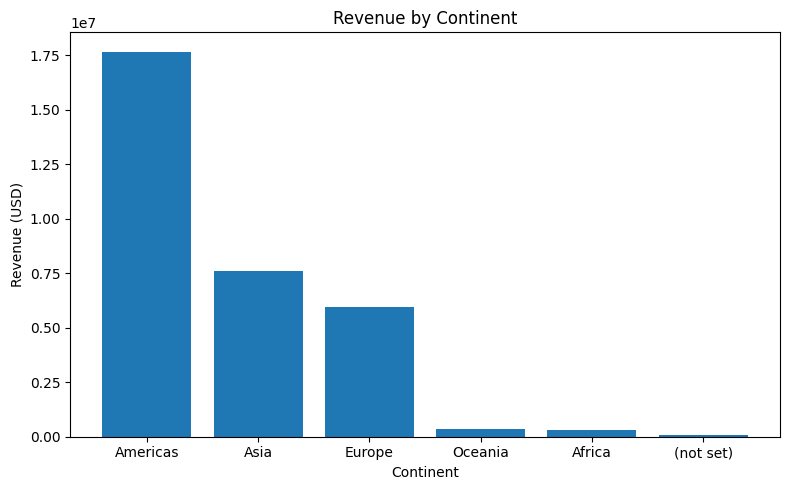

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    revenue_by_continent["continent"],
    revenue_by_continent["revenue"]
)

plt.title("Revenue by Continent")
plt.xlabel("Continent")
plt.ylabel("Revenue (USD)")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# KPI 3 — Revenue by Country (revenue + revenue_share)
# ============================================================

revenue_by_country = (
    df.groupby("country", as_index=False)
      .agg(revenue=("price", "sum"))
      .sort_values("revenue", ascending=False)
)

revenue_by_country["revenue_share"] = (
    revenue_by_country["revenue"] /
    total_revenue * 100
).round(2)

top5_countries = revenue_by_country.head(5)

top5_countries

,country,revenue,revenue_share
104,United States,13943553.9,43.61
43,India,2809762.0,8.79
18,Canada,2437921.0,7.63
103,United Kingdom,938317.9,2.93
33,France,710692.8,2.22


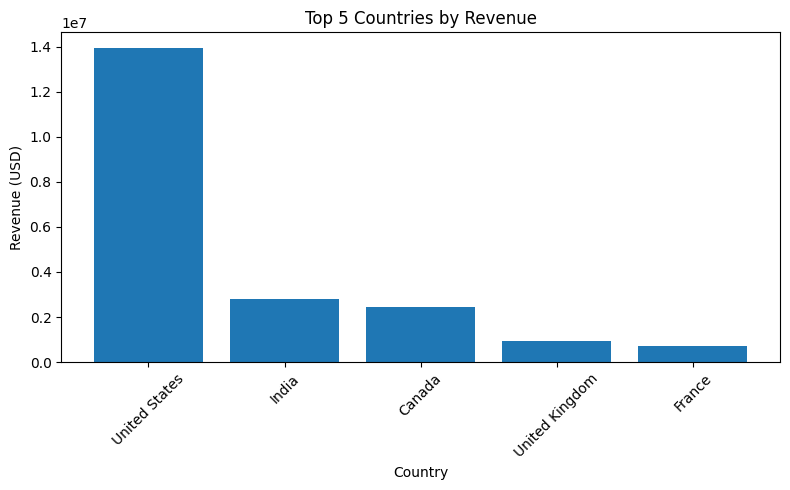

In [ ]:
# ============================================================
# Top 5 Countries by Revenue
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    top5_countries["country"],
    top5_countries["revenue"]
)

plt.title("Top 5 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insights

- Total revenue: **31.97M USD**.
- Americas alone: **55.25%** of revenue.
- US led with **13.94M** — India was #2, far behind at **2.81M**.
- Top-3 continents = **97.59%** of sales. The remaining markets contributed just **2.41%**.

# 2. Product Performance 📦

## Business Question

Which products and categories actually drive the revenue?

## KPIs

The following KPIs will be analyzed:

- Revenue by Product Category
- Top 10 Products by Revenue
- Products Sold
- Average Product Price

These KPIs evaluate product performance by combining revenue, sales volume, and pricing information.

In [ ]:
# ============================================================
# KPI 1 — Revenue by Product Category
# ============================================================

revenue_by_category = (
    df.groupby("product_category", as_index=False)
      .agg(
          revenue=("price", "sum")
      )
      .sort_values("revenue", ascending=False)
)

revenue_by_category["revenue_share"] = (
    revenue_by_category["revenue"] /
    total_revenue * 100
).round(2)

revenue_by_category

,product_category,revenue,revenue_share
12,Sofas & armchairs,8388254.5,26.24
5,Chairs,6147748.8,19.23
1,Beds,4919725.0,15.39
2,Bookcases & shelving units,3640818.1,11.39
3,Cabinets & cupboards,2336499.5,7.31
9,Outdoor furniture,2142222.2,6.70
13,Tables & desks,1790307.5,5.60
6,Chests of drawers & drawer units,906562.5,2.84
0,Bar furniture,735503.0,2.30
7,Children's furniture,467697.0,1.46


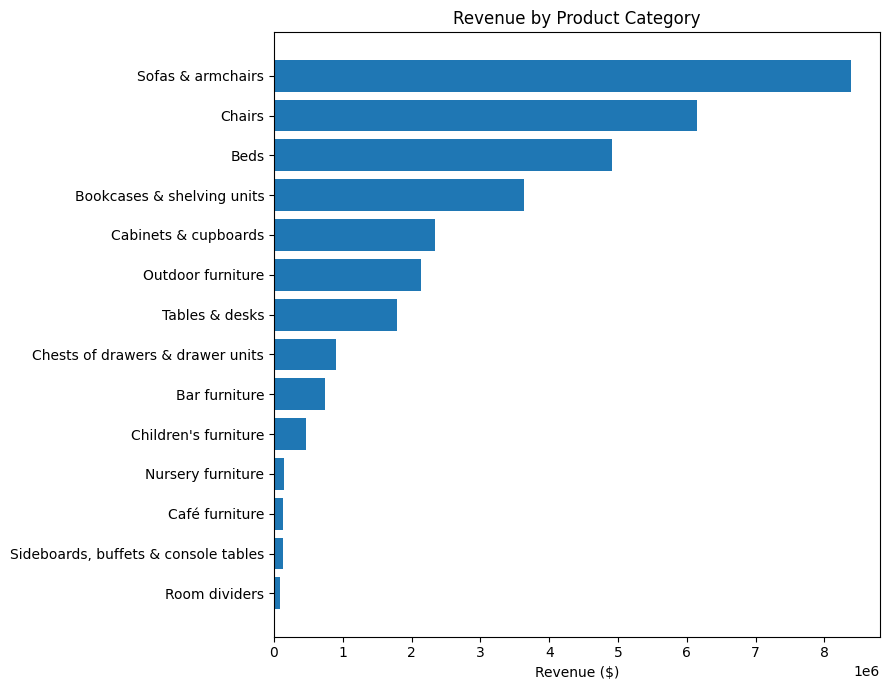

In [ ]:
plt.figure(figsize=(9, 7))

plt.barh(
    revenue_by_category["product_category"][::-1],
    revenue_by_category["revenue"][::-1]
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue ($)")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Concentration check: top-3 vs bottom-5 categories
# ------------------------------------------------------------
top3_share = revenue_by_category.head(3)["revenue_share"].sum().round(2)
bottom5_share = revenue_by_category.tail(5)["revenue_share"].sum().round(2)

print(f"Top-3 categories share: {top3_share}%")
print(f"Bottom-5 categories share: {bottom5_share}%")

Top-3 categories share: 60.86%
Bottom-5 categories share: 3.01%


In [ ]:
# ============================================================
# KPI 2 — Top 10 Products by Revenue
# ============================================================

top10_products = (
    df.groupby("product_name", as_index=False)
      .agg(
          revenue=("price", "sum")
      )
      .sort_values("revenue", ascending=False)
      .head(10)
)

top10_products["revenue_share"] = (
    top10_products["revenue"] /
    total_revenue * 100
).round(2)

top10_products

,product_name,revenue,revenue_share
155,GRÖNLID,2299190.0,7.19
261,LIDHULT,2257508.0,7.06
527,VIMLE,1710015.0,5.35
29,BESTÅ,1100634.5,3.44
513,VALLENTUNA,1014376.0,3.17
216,KIVIK,877763.0,2.75
21,BEKANT,797761.0,2.50
167,HAVSTA,627430.0,1.96
439,SOLLERÖN,604380.0,1.89
378,NORSBORG,590140.0,1.85


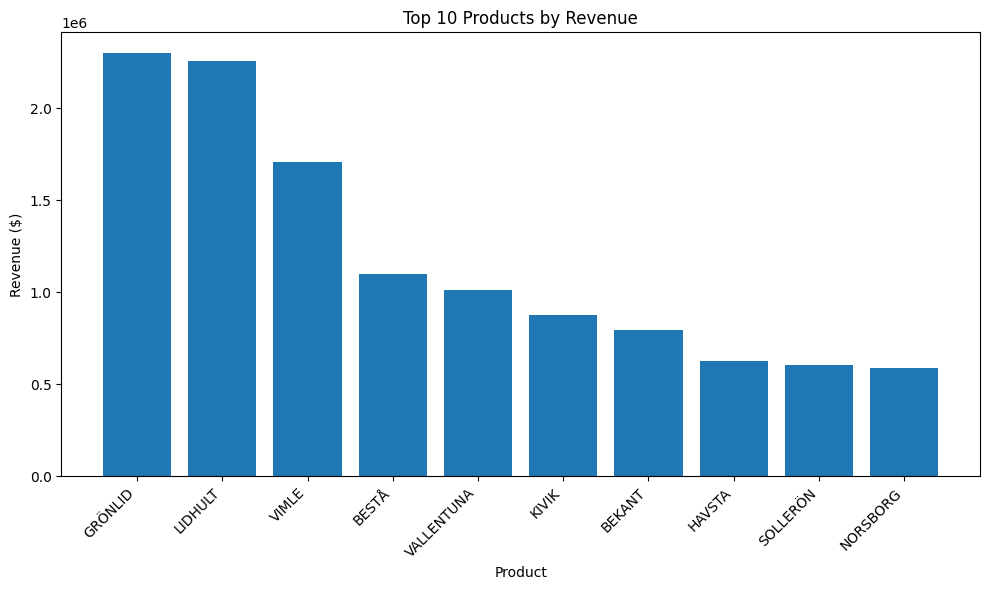

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    top10_products["product_name"],
    top10_products["revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Concentration check: top-10 products vs total revenue
# ------------------------------------------------------------
top10_products_share = top10_products["revenue_share"].sum().round(2)

print(f"Top 10 products share: {top10_products_share}%")

Top 10 products share: 37.16%


In [ ]:
# ============================================================
# KPI 3 — Products Sold
# ============================================================

products_sold = df["product_name"].count()

print(f"Total products sold: {products_sold:,}")

Total products sold: 33,538


In [ ]:
# ============================================================
# KPI 4 — Average Product Price
# ============================================================

average_product_price = df["price"].mean()

print(f"Average product price: ${average_product_price:,.2f}")

median_product_price = df["price"].median()
print(f"Median product price: ${median_product_price:,.2f}")

Average product price: $953.30
Median product price: $445.00


## Insights

- Sofas & armchairs generated the highest revenue: **8.39M USD (26.24%)**.
- **GRÖNLID** was the top-performing product with revenue of **2.30M USD (7.19%)**.
- A total of **33,538** products were sold. The average product price was **953.30 USD**, while the median price was **445 USD**, indicating that premium products increased the overall average.
- The top three product categories generated **60.86%** of total revenue, while the top ten products accounted for **37.16%**.

# 3. Customer Segmentation 👥


## Business Question

Which customer segments generate the greatest business value and customer engagement?

## KPIs

### Core KPIs

- Unique Sessions
- Registered Users
- Registered User Rate
- Revenue per Session
- Revenue by Traffic Channel
- Revenue by Device

### Customer Quality Metrics

- Verified Email Rate
- Newsletter Unsubscription Rate

In [ ]:
# ============================================================
# KPI 1 — Unique Sessions & Registered Users
# ============================================================

unique_sessions = df["session_id"].nunique()
registered_users = df["user_id"].nunique()

print(f"Unique sessions: {unique_sessions:,}")
print(f"Registered users: {registered_users:,}")

Unique sessions: 349,545
Registered users: 27,945


In [ ]:
# ============================================================
# KPI 2 — Registered User Rate
# ============================================================

registered_user_rate = (
    registered_users / unique_sessions * 100
)

print(f"Registered User Rate: {registered_user_rate:.2f}%")

Registered User Rate: 7.99%


In [ ]:
# ============================================================
# KPI 3 — Revenue per Session
# ============================================================

revenue_per_session = total_revenue / unique_sessions

print(f"Revenue per session: {revenue_per_session:.2f} USD")

Revenue per session: 91.47 USD


In [ ]:
# ============================================================
# KPI 4 — Revenue by Traffic Channel
# ============================================================

revenue_by_channel = (
    df.groupby("traffic_channel", as_index=False)["price"]
      .sum()
      .rename(columns={"price": "revenue"})
      .sort_values("revenue", ascending=False)
)

revenue_by_channel["revenue_share"] = (
    revenue_by_channel["revenue"] / total_revenue * 100
).round(2)

revenue_by_channel

,traffic_channel,revenue,revenue_share
1,Organic Search,11433151.6,35.76
2,Paid Search,8511049.4,26.62
0,Direct,7494923.4,23.44
3,Social Search,2532105.7,7.92
4,Undefined,2000501.0,6.26


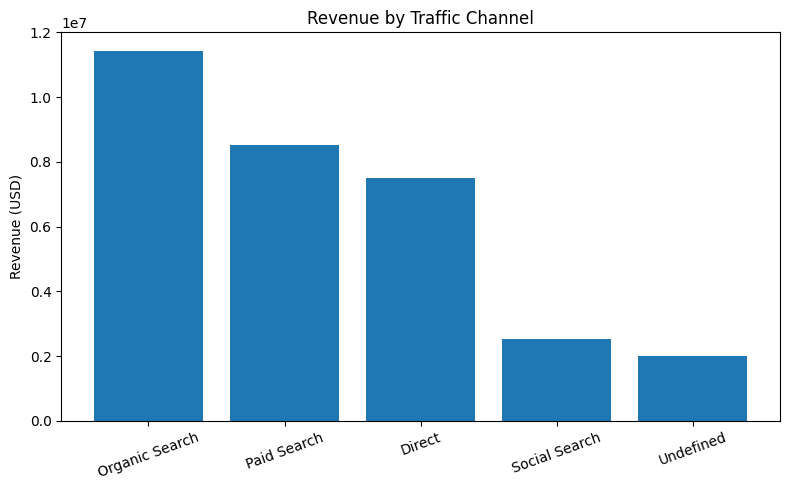

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    revenue_by_channel["traffic_channel"],
    revenue_by_channel["revenue"]
)

plt.title("Revenue by Traffic Channel")
plt.xlabel("")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# KPI 5 — Revenue by Device
# ============================================================

revenue_by_device = (
    df.groupby("device", as_index=False)["price"]
      .sum()
      .rename(columns={"price": "revenue"})
      .sort_values("revenue", ascending=False)
)

revenue_by_device["revenue_share"] = (
    revenue_by_device["revenue"] / total_revenue * 100
).round(2)

revenue_by_device

,device,revenue,revenue_share
0,desktop,18864039.0,59.00
1,mobile,12384225.8,38.73
2,tablet,723466.3,2.26


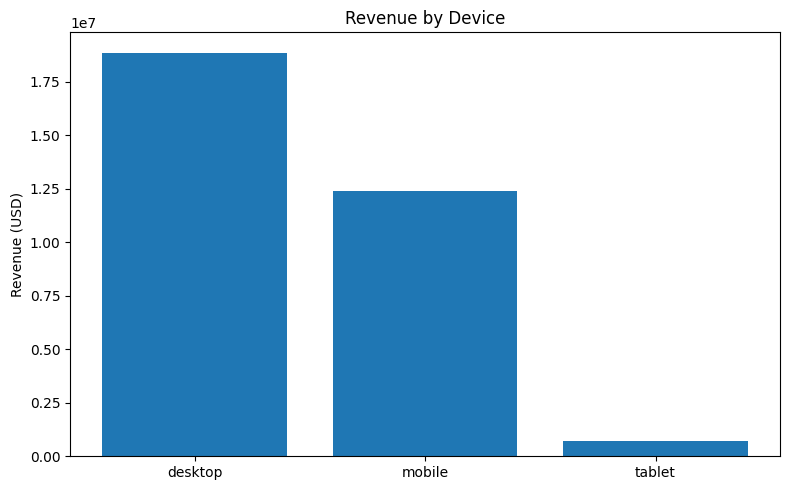

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    revenue_by_device["device"],
    revenue_by_device["revenue"]
)

plt.title("Revenue by Device")
plt.xlabel("")
plt.ylabel("Revenue (USD)")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# KPI 6 — Verified Email Rate
# ============================================================

verified_email_rate = (
    df["confirmed_email"]
      .mean() * 100
)

print(f"Verified Email Rate: {verified_email_rate:.2f}%")

Verified Email Rate: 71.70%


In [ ]:
# ------------------------------------------------------------
# Verification: check value distribution behind Verified Email Rate
# ------------------------------------------------------------
df["confirmed_email"].value_counts(dropna=False)

,count
confirmed_email,
<NA>,321600
1,20036
0,7909


In [ ]:
# ============================================================
# KPI 7 — Newsletter Unsubscription Rate
# ============================================================

newsletter_unsubscription_rate = (
    df["newsletter_unsubscribed"]
      .mean() * 100
)

print(f"Newsletter Unsubscription Rate: {newsletter_unsubscription_rate:.2f}%")

Newsletter Unsubscription Rate: 16.94%


In [ ]:
# ------------------------------------------------------------
# Verification: check value distribution behind Newsletter Unsubscription Rate
# ------------------------------------------------------------
df["newsletter_unsubscribed"].value_counts(dropna=False)

,count
newsletter_unsubscribed,
<NA>,321600
0,23210
1,4735


## Insights
- 349,545 sessions total, with **27,945** registered users (**7.99%** of session volume).
- Average revenue per session: **$91.47**.
- Desktop generated **59.00%** of total revenue vs **38.73%** from mobile; tablet barely registers at **2.26%**.
- Organic Search was the largest revenue source (**35.76%**); Paid Search came second at **26.62%**.
- Among registered users, **71.70%** verified their email, while only **16.94%** unsubscribed — the base looks reasonably engaged.

# 4. Sales Trend 📈


## Business Question
How did sales performance change over time, and are there recurring trends or seasonal patterns?

## KPIs

- Revenue Trend
- Sales Trend by Continent
- Sales Trend by Traffic Channel
- Sales Trend by Device

In [ ]:
# ============================================================
# KPI 1 — Revenue Trend
# ============================================================

# ------------------------------------------------------------
# Daily Revenue
# ------------------------------------------------------------
daily_revenue = (
    df.groupby("order_date", as_index=False)["price"]
      .sum()
      .rename(columns={"price": "revenue"})
      .sort_values("order_date")
)

daily_revenue.head()

,order_date,revenue
0,2020-11-01,244292.5
1,2020-11-02,355506.8
2,2020-11-03,498979.6
3,2020-11-04,339187.1
4,2020-11-05,391276.6


In [ ]:
# ------------------------------------------------------------
# 7-Day Rolling Average
# ------------------------------------------------------------
daily_revenue["rolling_7d"] = (
    daily_revenue["revenue"]
        .rolling(window=7)
        .mean()
)

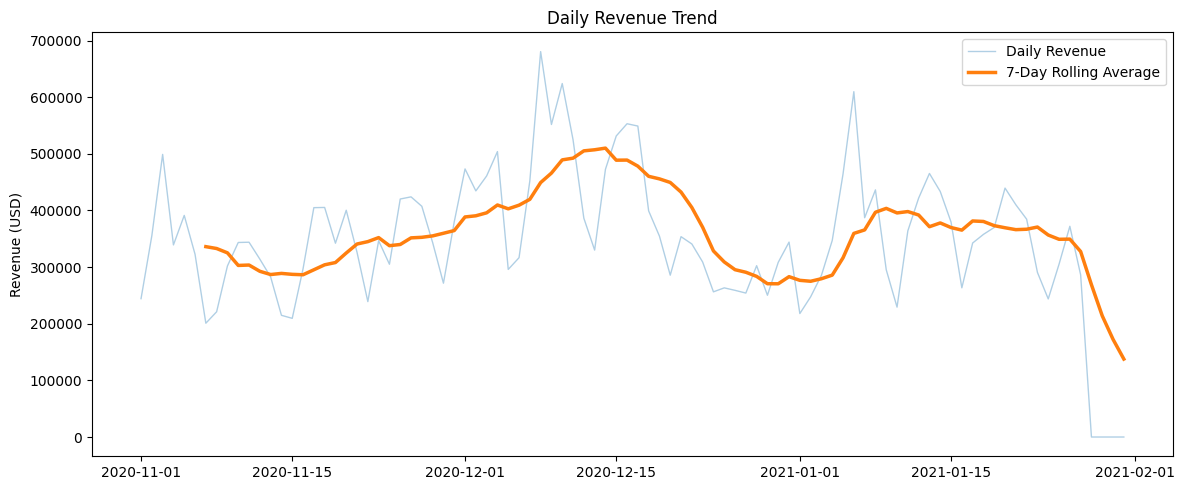

In [ ]:
# ------------------------------------------------------------
# Daily Revenue Trend — Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    daily_revenue["order_date"],
    daily_revenue["revenue"],
    alpha=0.35,
    linewidth=1,
    label="Daily Revenue"
)
plt.plot(
    daily_revenue["order_date"],
    daily_revenue["rolling_7d"],
    linewidth=2.5,
    label="7-Day Rolling Average"
)

plt.title("Daily Revenue Trend")
plt.xlabel("")
plt.ylabel("Revenue (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Monthly Revenue
# ------------------------------------------------------------
monthly_revenue = (
    df.groupby(df["order_date"].dt.to_period("M"))["price"]
      .sum()
      .reset_index()
      .rename(columns={"price": "revenue"})
)

monthly_revenue["order_date"] = (
    monthly_revenue["order_date"].dt.to_timestamp()
)

monthly_revenue

,order_date,revenue
0,2020-11-01,9897515.0
1,2020-12-01,12423439.3
2,2021-01-01,9650776.8


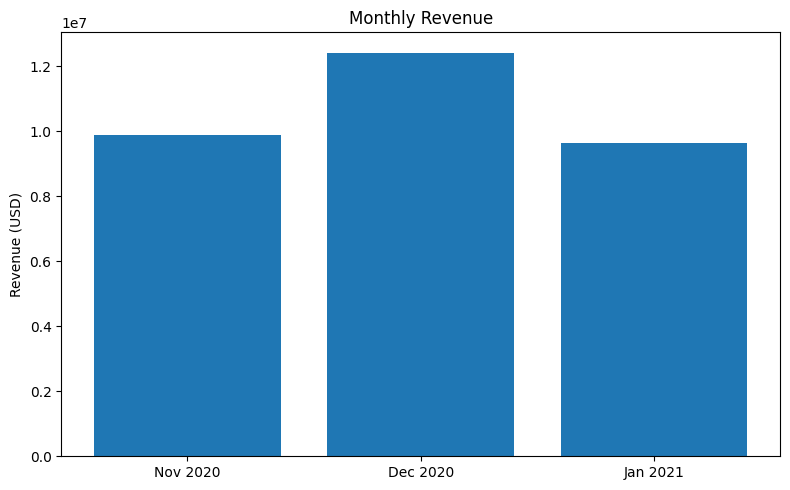

In [ ]:
# ------------------------------------------------------------
# Monthly Revenue — Visualization
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.bar(
    monthly_revenue["order_date"].dt.strftime("%b %Y"),
    monthly_revenue["revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

**Data Quality Note:** Revenue is $0 from **2021-01-28 to 2021-01-31** — all transactions in this window are missing `price` values. The apparent drop at the end of January (visible in both charts) reflects incomplete data, not an actual sales decline. January's monthly total is therefore understated.

In [ ]:
# ============================================================
# KPI 2 — Sales Trend by Continent
# ============================================================

continent_trend = (
    df[df["continent"].isin(["Americas", "Asia", "Europe"])]
      .groupby(["order_date", "continent"])["price"]
      .sum()
      .reset_index()
)

continent_trend.head()

,order_date,continent,price
0,2020-11-01,Americas,132002.5
1,2020-11-01,Asia,63823.0
2,2020-11-01,Europe,46908.0
3,2020-11-02,Americas,193861.0
4,2020-11-02,Asia,79370.0


In [ ]:
# ============================================================
# Pivot table
# ============================================================

continent_trend_pivot = (
    continent_trend
        .pivot(
            index="order_date",
            columns="continent",
            values="price"
        )
        .fillna(0)
)

continent_trend_pivot.head()

continent,Americas,Asia,Europe
order_date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0


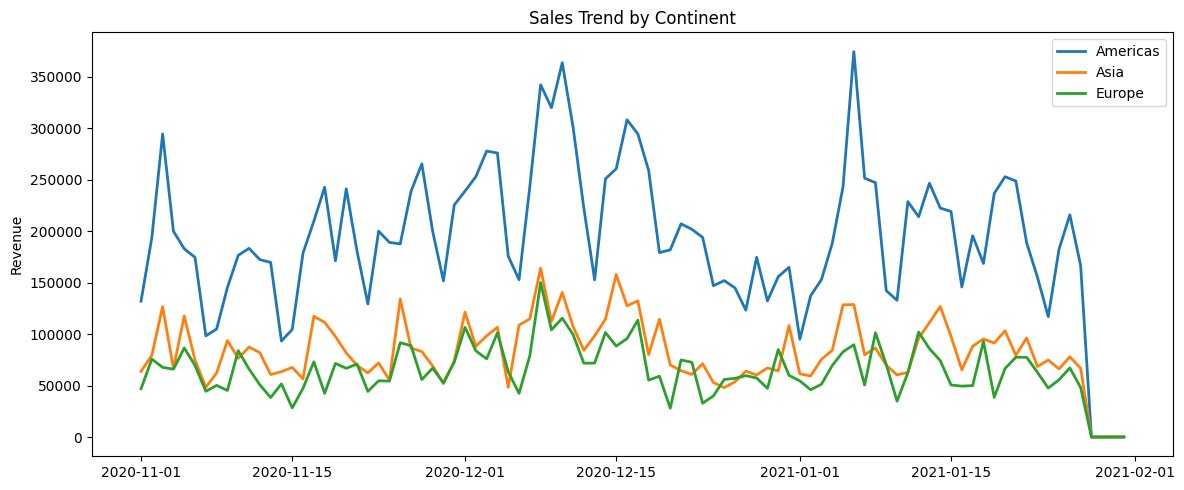

In [ ]:
plt.figure(figsize=(12,5))

for continent in continent_trend_pivot.columns:
    plt.plot(
        continent_trend_pivot.index,
        continent_trend_pivot[continent],
        linewidth=2,
        label=continent
    )

plt.title("Sales Trend by Continent")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# KPI 2 — Sales Trend by Traffic Channel
# ============================================================

traffic_trend = (
    df[df["traffic_channel"] != "Undefined"]
      .groupby(["order_date", "traffic_channel"], as_index=False)["price"]
      .sum()
      .rename(columns={"price": "revenue"})
)

traffic_trend.head()

,order_date,traffic_channel,revenue
0,2020-11-01,Direct,54669.5
1,2020-11-01,Organic Search,95112.0
2,2020-11-01,Paid Search,64688.0
3,2020-11-01,Social Search,25078.0
4,2020-11-02,Direct,81561.5


In [ ]:
traffic_trend_pivot = (
    traffic_trend
        .pivot(
            index="order_date",
            columns="traffic_channel",
            values="revenue"
        )
)

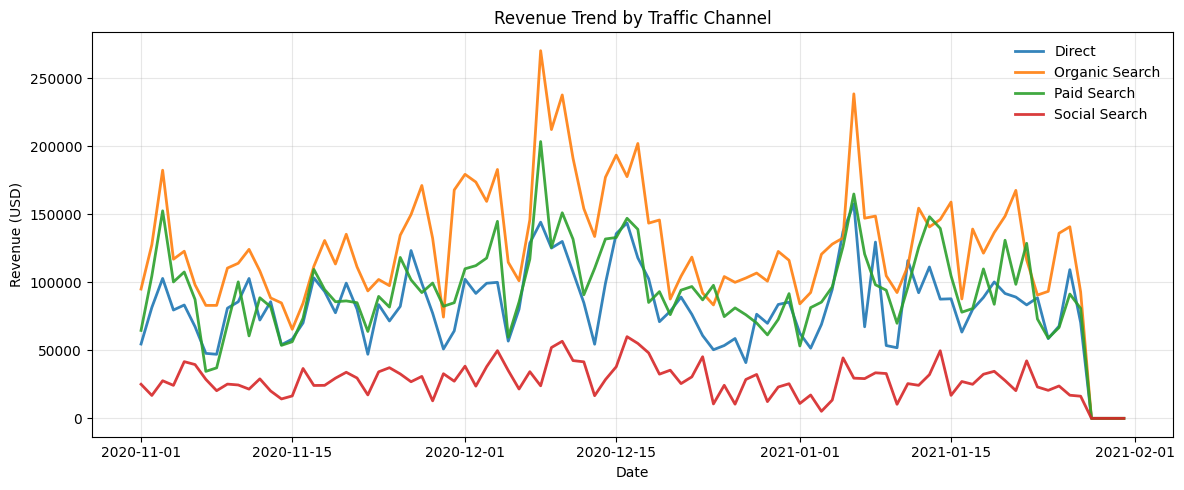

In [ ]:
plt.figure(figsize=(12,5))

for channel in traffic_trend_pivot.columns:
    plt.plot(
        traffic_trend_pivot.index,
        traffic_trend_pivot[channel],
        linewidth=2,
        alpha=0.9,
        label=channel
    )

plt.title("Revenue Trend by Traffic Channel")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# Note: "Undefined" traffic excluded from trend view —
# represents untracked sessions, not a real acquisition channel.

In [ ]:
# ============================================================
# KPI 4 — Sales Trend by Device
# ============================================================

device_trend = (
    df.groupby(["order_date", "device"], as_index=False)["price"]
      .sum()
      .rename(columns={"price": "revenue"})
)

device_trend.head()

,order_date,device,revenue
0,2020-11-01,desktop,144445.0
1,2020-11-01,mobile,99698.5
2,2020-11-01,tablet,149.0
3,2020-11-02,desktop,206727.3
4,2020-11-02,mobile,137269.5


In [ ]:
device_trend_pivot = (
    device_trend
    .pivot(index="order_date",
           columns="device",
           values="revenue")
    .fillna(0)
)

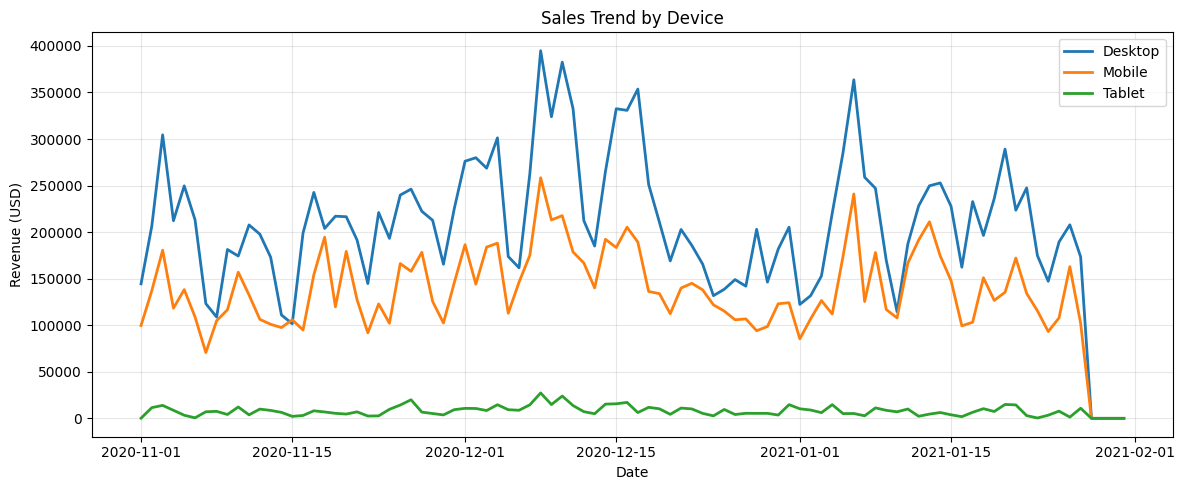

In [ ]:
plt.figure(figsize=(12, 5))

for device in device_trend_pivot.columns:
    plt.plot(
        device_trend_pivot.index,
        device_trend_pivot[device],
        linewidth=2,
        label=device.capitalize()
    )

plt.title("Sales Trend by Device")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Insights

- Revenue peaked in mid-December (680K USD/day at the high point) — likely holiday shopping season.
- Data is incomplete for **Jan 28–31**: all transactions in this window have missing `price`, causing an artificial drop to 0. Both daily and monthly totals for January are understated.
- **Americas** consistently outsells Asia and Europe every single day — not driven by isolated spikes. Asia and Europe track closely together throughout the period.
- **Organic Search** leads traffic-driven revenue on most days, followed closely by Paid Search during peak periods; Social Search stays flat and low throughout.
- **Desktop** dominates over Mobile on nearly every day, with Tablet contributing almost nothing — device preference is stable over time, not seasonal.

# 5. Pivot Tables 🔢


Cross-tabulated views to explore multi-dimensional relationships in the data.

## KPIs
- Sessions by Traffic Channel & Device
- Revenue by Top-10 Categories & Top-5 Countries
- Revenue by Continent & Device

In [ ]:
# ============================================================
# Pivot Table 1 — Sessions by Traffic Channel & Device
# ============================================================

sessions_pivot = pd.pivot_table(
    df[df["traffic_channel"] != "Undefined"],
    index="traffic_channel",
    columns="device",
    values="session_id",
    aggfunc="nunique",
    fill_value=0
)

sessions_pivot

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


In [ ]:
# ============================================================
# Pivot Table 2 — Revenue by Top-10 Categories & Top-5 Countries
# ============================================================

top10_categories_list = revenue_by_category.head(10)["product_category"].tolist()
top5_countries_list = top5_countries["country"].tolist()

category_country_pivot = pd.pivot_table(
    df[
        df["product_category"].isin(top10_categories_list) &
        df["country"].isin(top5_countries_list)
    ],
    index="product_category",
    columns="country",
    values="price",
    aggfunc="sum",
    fill_value=0
)

category_country_pivot

country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


In [ ]:
# ============================================================
# Pivot Table 3 — Revenue by Continent & Device
# ============================================================

top3_continents_list = ["Americas", "Asia", "Europe"]

continent_device_pivot = pd.pivot_table(
    df[df["continent"].isin(top3_continents_list)],
    index="continent",
    columns="device",
    values="price",
    aggfunc="sum",
    fill_value=0
)

continent_device_pivot

device,desktop,mobile,tablet
continent,,,
Americas,10497307.4,6780364.3,387608.3
Asia,4381094.4,3028054.4,192149.5
Europe,3493992.9,2311532.8,129098.5


## Insights

- Organic Search leads sessions on every device: 72,622 desktop, 49,014 mobile, 2,789 tablet. Same story everywhere — it wins.
- US dominates every single product category, often 5-10x the next country. India consistently takes #2 across categories like Beds, Chairs, and Bookcases.
- Desktop-to-mobile revenue ratio is nearly identical across Americas, Asia, and Europe (~1.5x) — device preference doesn't vary much by region.

# 6. Statistical Validation 📊


## Business Question
Which observed relationships are statistically significant, and which could be due to chance?

## Method
Correlations tested with Pearson's r; group comparisons use the appropriate test based on data distribution.


In [ ]:
# ============================================================
# Test 1 — Sessions vs Revenue
# ============================================================

daily_sessions = (
    df.groupby("order_date", as_index=False)["session_id"]
    .nunique()
    .rename(columns={"session_id": "sessions"})
)

daily_combined = (
    daily_revenue[["order_date", "revenue"]]
    .merge(daily_sessions, on="order_date", how="inner")
)

corr_sess, p_sess = pearsonr(
    daily_combined["sessions"],
    daily_combined["revenue"]
)

print(f"Correlation coefficient: {corr_sess:.3f}")
print(f"p-value: {p_sess:.4f}")

Correlation coefficient: 0.791
p-value: 0.0000


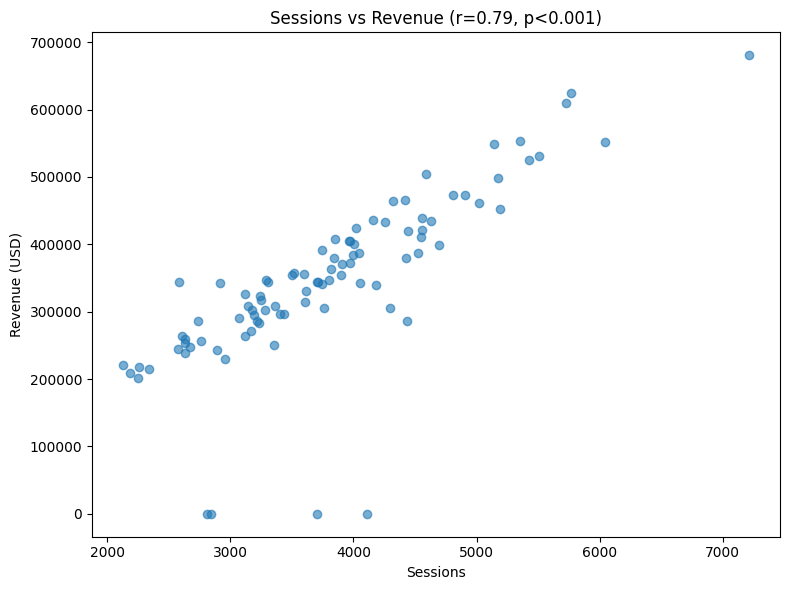

In [ ]:
# ============================================================
# Sessions vs Revenue — Visualization
# ============================================================

p_label = (
    "<0.001"
    if p_sess < 0.001
    else f"{p_sess:.4f}"
)

plt.figure(figsize=(8, 6))

plt.scatter(
    daily_combined["sessions"],
    daily_combined["revenue"],
    alpha=0.6
)

plt.title(
    f"Sessions vs Revenue (r={corr_sess:.2f}, p{p_label})"
)

plt.xlabel("Sessions")
plt.ylabel("Revenue (USD)")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Test 2 — Sales Correlation Across Continents
# ============================================================

continent_corr = (
    continent_trend_pivot[
        ["Americas", "Asia", "Europe"]
    ]
    .corr()
)

continent_corr.round(3)

continent,Americas,Asia,Europe
continent,,,
Americas,1.000,0.792,0.771
Asia,0.792,1.000,0.768
Europe,0.771,0.768,1.000


In [ ]:
# ============================================================
# Test 2 — Pairwise p-values for Continents
# ============================================================

continent_pvalues = pd.DataFrame(
    np.ones(
        (len(continent_corr), len(continent_corr))
    ),
    index=continent_corr.index,
    columns=continent_corr.columns
)

for col_1 in continent_corr.columns:
    for col_2 in continent_corr.columns:
        if col_1 != col_2:
            _, p = pearsonr(
                continent_trend_pivot[col_1],
                continent_trend_pivot[col_2]
            )
            continent_pvalues.loc[col_1, col_2] = p

continent_pvalues.round(4)

continent,Americas,Asia,Europe
continent,,,
Americas,1.0,0.0,0.0
Asia,0.0,1.0,0.0
Europe,0.0,0.0,1.0


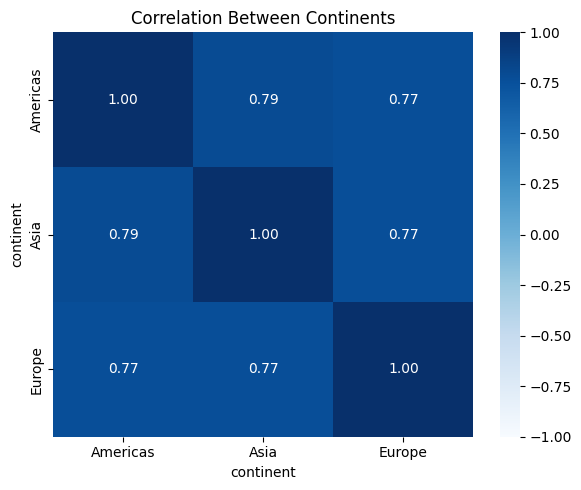

In [ ]:
# ============================================================
# Test 2 — Continents Correlation Heatmap
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    continent_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Continents")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Test 3 — Sales Correlation Across Traffic Channels
# ============================================================

channel_corr = traffic_trend_pivot.corr()

channel_corr.round(3)

traffic_channel,Direct,Organic Search,Paid Search,Social Search
traffic_channel,,,,
Direct,1.000,0.838,0.814,0.604
Organic Search,0.838,1.000,0.870,0.583
Paid Search,0.814,0.870,1.000,0.596
Social Search,0.604,0.583,0.596,1.000


In [ ]:
# ============================================================
# Test 3 — Pairwise p-values for Traffic Channels
# ============================================================

channel_pvalues = pd.DataFrame(
    np.ones(
        (len(channel_corr), len(channel_corr))
    ),
    index=channel_corr.index,
    columns=channel_corr.columns
)

for col_1 in channel_corr.columns:
    for col_2 in channel_corr.columns:
        if col_1 != col_2:
            _, p = pearsonr(
                traffic_trend_pivot[col_1],
                traffic_trend_pivot[col_2]
            )
            channel_pvalues.loc[col_1, col_2] = p

channel_pvalues.round(4)

traffic_channel,Direct,Organic Search,Paid Search,Social Search
traffic_channel,,,,
Direct,1.0,0.0,0.0,0.0
Organic Search,0.0,1.0,0.0,0.0
Paid Search,0.0,0.0,1.0,0.0
Social Search,0.0,0.0,0.0,1.0


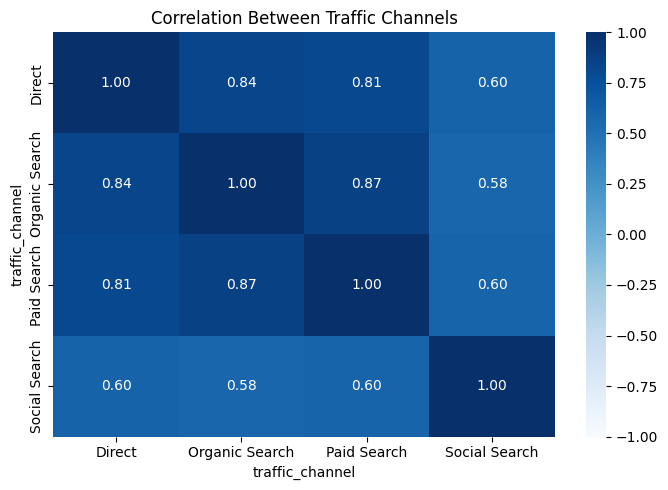

In [ ]:
# ============================================================
# Test 3 — Traffic Channels Correlation Heatmap
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    channel_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Traffic Channels")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Test 4 — Sales Correlation Across Top-5 Product Categories
# ============================================================

top5_categories_list = (
    revenue_by_category
    .head(5)["product_category"]
    .tolist()
)

category_trend = (
    df[
        df["product_category"].isin(top5_categories_list)
    ]
    .groupby(
        ["order_date", "product_category"]
    )["price"]
    .sum()
    .reset_index()
)

category_trend_pivot = (
    category_trend
    .pivot(
        index="order_date",
        columns="product_category",
        values="price"
    )
    .fillna(0)
)

category_corr = category_trend_pivot.corr()

category_corr.round(3)

product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.000,0.593,0.515,0.554,0.535
Bookcases & shelving units,0.593,1.000,0.539,0.637,0.666
Cabinets & cupboards,0.515,0.539,1.000,0.573,0.658
Chairs,0.554,0.637,0.573,1.000,0.578
Sofas & armchairs,0.535,0.666,0.658,0.578,1.000


In [ ]:
# ============================================================
# Test 4 — Pairwise p-values for Product Categories
# ============================================================

category_pvalues = pd.DataFrame(
    np.ones(
        (len(category_corr), len(category_corr))
    ),
    index=category_corr.index,
    columns=category_corr.columns
)

for col_1 in category_corr.columns:
    for col_2 in category_corr.columns:
        if col_1 != col_2:
            _, p = pearsonr(
                category_trend_pivot[col_1],
                category_trend_pivot[col_2]
            )
            category_pvalues.loc[col_1, col_2] = p

category_pvalues.round(4)

product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.0,0.0,0.0,0.0,0.0
Bookcases & shelving units,0.0,1.0,0.0,0.0,0.0
Cabinets & cupboards,0.0,0.0,1.0,0.0,0.0
Chairs,0.0,0.0,0.0,1.0,0.0
Sofas & armchairs,0.0,0.0,0.0,0.0,1.0


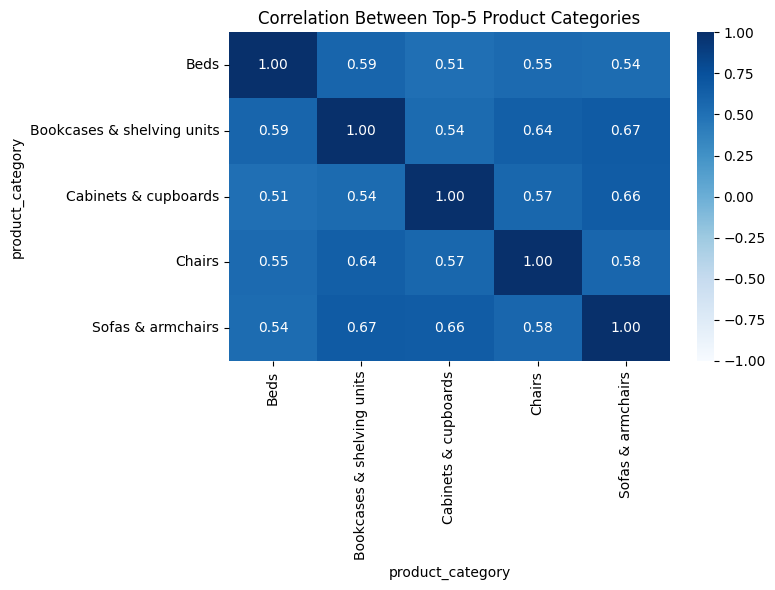

In [ ]:
# ============================================================
# Test 4 — Product Categories Correlation Heatmap
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    category_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Top-5 Product Categories")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Test 5 — Revenue vs Registered Users
# ============================================================

daily_registered = (
    df[df["user_id"].notna()]
    .groupby("order_date", as_index=False)["user_id"]
    .nunique()
    .rename(columns={"user_id": "registered_users"})
)

daily_users_revenue = (
    daily_revenue[
        ["order_date", "revenue"]
    ]
    .merge(
        daily_registered,
        on="order_date",
        how="left"
    )
    .fillna({"registered_users": 0})
)

corr_users, p_users = pearsonr(
    daily_users_revenue["registered_users"],
    daily_users_revenue["revenue"]
)

print(f"Correlation coefficient: {corr_users:.3f}")
print(f"p-value: {p_users:.4f}")

Correlation coefficient: 0.955
p-value: 0.0000


In [ ]:
# ============================================================
# Test 6 — Registered vs Anonymous
# Revenue per Session
# ============================================================

registered_data = df[
    df["user_id"].notna()
]

anonymous_data = df[
    df["user_id"].isna()
]

registered_daily = (
    registered_data
    .groupby("order_date")
    .apply(
        lambda x:
        x["price"].sum()
        / x["session_id"].nunique(),
        include_groups=False
    )
)

anonymous_daily = (
    anonymous_data
    .groupby("order_date")
    .apply(
        lambda x:
        x["price"].sum()
        / x["session_id"].nunique(),
        include_groups=False
    )
)

print(
    f"Registered mean revenue/session: "
    f"{registered_daily.mean():.2f}"
)

print(
    f"Anonymous mean revenue/session: "
    f"{anonymous_daily.mean():.2f}"
)

print(f"Registered n = {len(registered_daily)}")
print(f"Anonymous n = {len(anonymous_daily)}")

Registered mean revenue/session: 92.74
Anonymous mean revenue/session: 91.23
Registered n = 88
Anonymous n = 92


In [ ]:
# ============================================================
# Test 6 — Normality Check
# ============================================================

stat_reg, p_reg = shapiro(registered_daily)

stat_anon, p_anon = shapiro(anonymous_daily)

print(
    f"Registered normality p-value: "
    f"{p_reg:.4f}"
)

print(
    f"Anonymous normality p-value: "
    f"{p_anon:.4f}"
)

Registered normality p-value: 0.0028
Anonymous normality p-value: 0.0000


In [ ]:
# ============================================================
# Test 6 — Mann-Whitney U-test
# ============================================================

u_stat, p_mann = mannwhitneyu(
    registered_daily,
    anonymous_daily,
    alternative="two-sided"
)

print(f"U statistic: {u_stat:.2f}")
print(f"p-value: {p_mann:.4f}")

U statistic: 3619.00
p-value: 0.2201


In [ ]:
# ============================================================
# Statistical Test Summary
# ============================================================

def format_pvalue(p):
    return "<0.0001" if p < 0.0001 else f"{p:.4f}"


summary = pd.DataFrame({
    "Analysis": [
        "Sessions vs Revenue",
        "Top-3 Continents",
        "Traffic Channels",
        "Top-5 Categories",
        "Revenue vs Registered Users",
        "Registered vs Anonymous"
    ],

    "Statistical Test": [
        "Pearson correlation",
        "Pairwise Pearson correlations",
        "Pairwise Pearson correlations",
        "Pairwise Pearson correlations",
        "Pearson correlation",
        "Mann-Whitney U"
    ],

    "Result": [
        f"r = {corr_sess:.3f}",
        "r = 0.77–0.79",
        "r = 0.58–0.87",
        "r = 0.52–0.67",
        f"r = {corr_users:.3f}",
        (
            "Groups differ"
            if p_mann < 0.05
            else "No significant difference"
        )
    ],

    "p-value": [
        format_pvalue(p_sess),
        "all pairs < 0.001",
        "all pairs < 0.001",
        "all pairs < 0.001",
        format_pvalue(p_users),
        format_pvalue(p_mann)
    ],

    "Conclusion": [
        "Significant"
        if p_sess < 0.05
        else "Not significant",

        "All significant",
        "All significant",
        "All significant",

        "Significant"
        if p_users < 0.05
        else "Not significant",

        "Significant"
        if p_mann < 0.05
        else "Not significant"
    ]
})

summary

,Analysis,Statistical Test,Result,p-value,Conclusion
0,Sessions vs Revenue,Pearson correlation,r = 0.791,<0.0001,Significant
1,Top-3 Continents,Pairwise Pearson correlations,r = 0.77–0.79,all pairs < 0.001,All significant
2,Traffic Channels,Pairwise Pearson correlations,r = 0.58–0.87,all pairs < 0.001,All significant
3,Top-5 Categories,Pairwise Pearson correlations,r = 0.52–0.67,all pairs < 0.001,All significant
4,Revenue vs Registered Users,Pearson correlation,r = 0.955,<0.0001,Significant
5,Registered vs Anonymous,Mann-Whitney U,No significant difference,0.2201,Not significant


## Statistical Insights

- Sessions and revenue show a strong positive relationship (r = 0.791, p < 0.0001), indicating that days with higher traffic generally generated higher revenue.

- Revenue across the three largest continents is strongly correlated (r = 0.77–0.79, all pairs significant). This suggests that regional sales are influenced by common factors such as seasonality, promotions, or company-wide demand patterns.

- Organic Search and Paid Search show a very strong positive correlation (r = 0.870). Social Search has weaker correlations with the other channels (r = 0.583–0.596), suggesting that its revenue dynamics may be influenced by different campaign or audience factors.

- The top five product categories show moderate positive correlations (r = 0.52–0.67). This indicates that while categories are affected by common demand patterns, their sales dynamics are not identical.

- Registered users have a very strong positive correlation with daily revenue (r = 0.955, p < 0.0001). However, correlation does not imply causation, so this relationship may reflect a common underlying factor such as overall traffic or purchase activity.

- Registered users generated 92.74 USDT per session compared with 91.23 USDT for anonymous users. The Mann-Whitney U-test (U = 3619, p = 0.2201) found no statistically significant difference between the two groups.

# Recommendations


1. Organic Search brings the largest share of revenue (35.76%, 11.43M USDT). Before increasing the marketing budget, it is worth reviewing which SEO activities drive this performance and whether the same approach can be transferred to Paid Search.

2. The Americas remain the strongest market (55.25%, 17.67M USDT). Asia and Europe follow a similar pattern, so testing successful American campaigns there may make more sense than building separate strategies from scratch.

3. Desktop still drives most purchases (59.00%, 18.86M USDT vs 38.73% mobile). Mobile is worth monitoring, but desktop improvements may deliver faster returns.

4. Top product categories move together (r = 0.52–0.67) — seasonal demand affects several categories simultaneously, so promotions should be planned at the portfolio level rather than product by product.

5. Registered users correlate strongly with daily revenue (r = 0.955). This does not prove that registration causes higher revenue, but it provides a strong signal to investigate retention and account-creation strategies.

6. Missing price values for Jan 28–31 reduced reported revenue to zero for those days. Automated data-quality validation should be added before this type of issue reaches a live dashboard.

# Executive Summary

## Executive Summary

Days with more sessions almost always brought higher revenue (r = 0.791). An even stronger relationship was found between registered users and daily revenue (r = 0.955).

Three patterns consistently appeared across the analysis: the Americas led revenue (55.25%, 17.67M USDT), Organic Search remained the top revenue channel (35.76%, 11.43M USDT), and Desktop generated more revenue than Mobile and Tablet (59.00% vs 38.73% vs 2.26%).

Not every observed difference was statistically significant. Registered users generated 92.74 USDT per session compared with 91.23 USDT for anonymous users. However, the Mann-Whitney U-test (p = 0.2201) found no statistically significant difference between the two groups.

Revenue dropped to zero from Jan 28 to Jan 31, but this was caused by missing price data rather than an actual sales decline. Without a data-quality check, this could lead to an incorrect business conclusion.

Overall, the analysis suggests that maintaining strong acquisition channels, investigating opportunities to increase registration, and improving data-quality validation should be key priorities for future analysis.

# Tableau Dashboard

The final interactive dashboard was created in Tableau Public.

It summarizes the key findings from this analysis and provides an executive-level overview of sales performance.

The dashboard contains two pages:

- Executive Overview
- Sales Performance

Tableau Public link:[View on Tableau Public](https://public.tableau.com/views/GlobalE-commerceSalesPerformanceAnalysis/ExecutiveOverview?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

In [ ]:
# ============================================================
# Export cleaned dataset for Tableau Public
# ============================================================

from google.colab import files

df.to_csv("ecommerce_clean.csv", index=False)
files.download("ecommerce_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>